In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE


In [2]:
df = pd.read_csv('/content/customer_churn_dataset-testing-master.csv.zip')
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [3]:
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

In [5]:
if df['Total Spend'].dtype == 'object':
    df['Total Spend'] = pd.to_numeric(df['Total Spend'], errors='coerce')

In [6]:
df.dropna(inplace=True)

In [9]:
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])
df = pd.get_dummies(df, drop_first=True)

In [8]:
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
print(f"\nOriginal Training Shape: {X_train.shape}")
print(f"Class distribution before SMOTE: \n{y_train.value_counts()}")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


Original Training Shape: (51499, 13)
Class distribution before SMOTE: 
Churn
0    27088
1    24411
Name: count, dtype: int64


In [12]:
clf = DecisionTreeClassifier(random_state=42, max_depth=5, criterion='gini')
clf.fit(X_train_resampled, y_train_resampled)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [13]:
y_pred = clf.predict(X_test)
print("\n--- Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


--- Model Evaluation ---
Accuracy Score: 0.96

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.94      0.96      6793
           1       0.93      0.98      0.96      6082

    accuracy                           0.96     12875
   macro avg       0.96      0.96      0.96     12875
weighted avg       0.96      0.96      0.96     12875



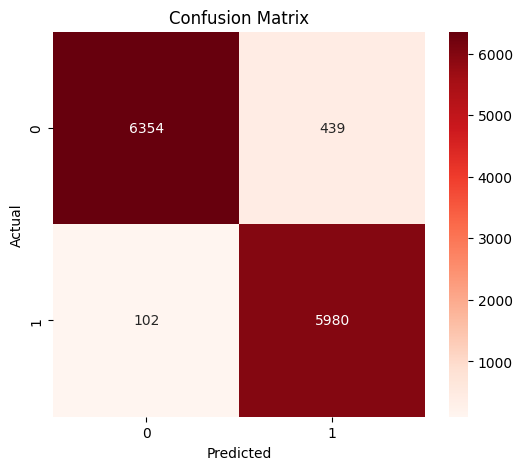

In [19]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

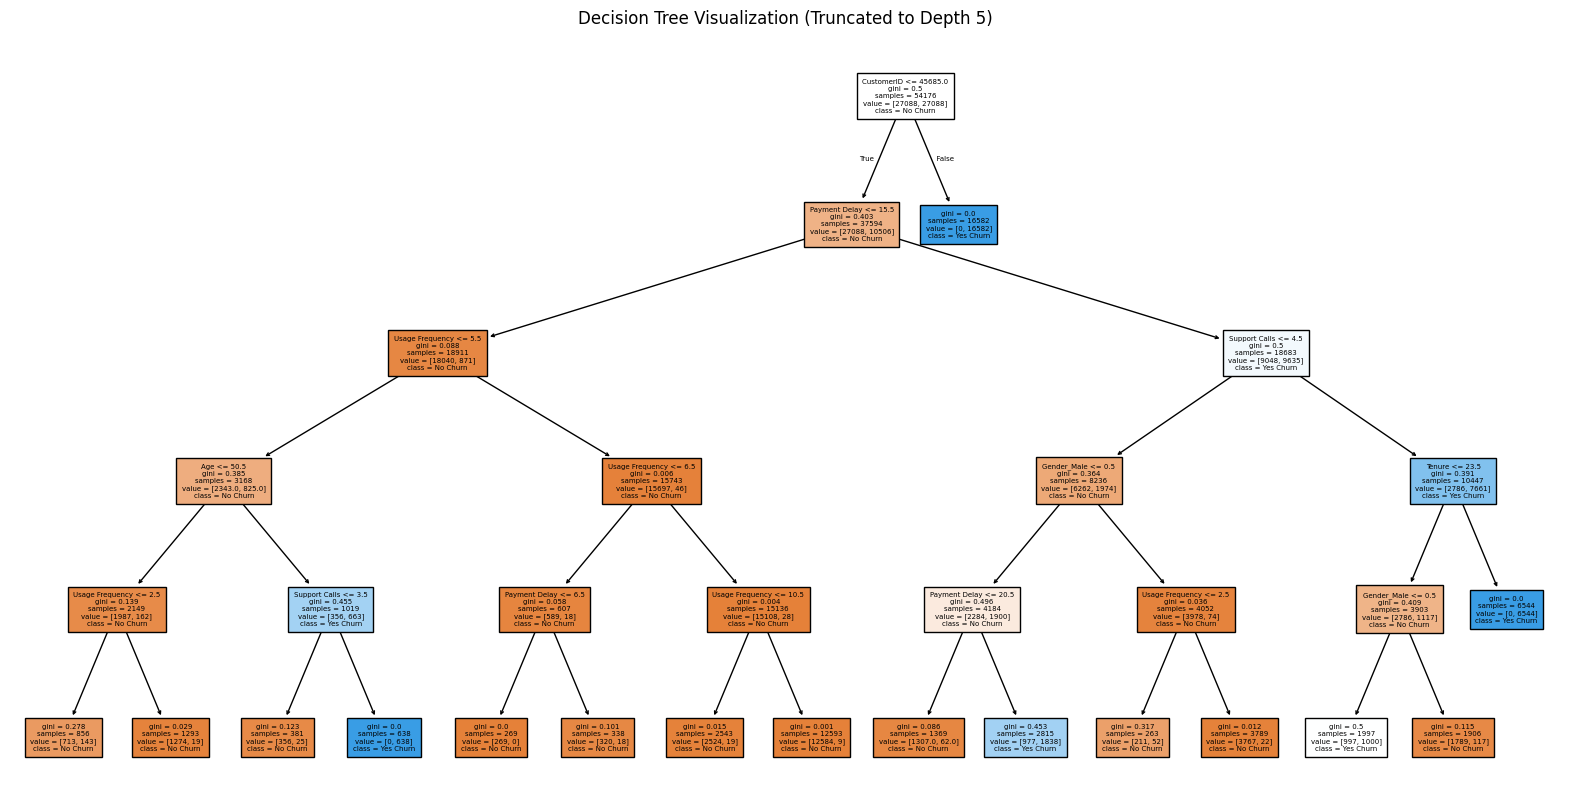

In [20]:
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=['No Churn', 'Yes Churn'], filled=True, fontsize=5)
plt.title("Decision Tree Visualization (Truncated to Depth 5)")
plt.show()